<a href="https://colab.research.google.com/github/UNICODEY/mnist-fc-vs-cnn/blob/main/mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MNIST Digit Classification: Fully-Connected vs CNN
# Comparing two architectures and analysing where each model fails.

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

print(f"Train set: {len(train_data)} images")
print(f"Test set:  {len(test_data)} images")
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}  — [batch, channels, height, width]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 356kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.99MB/s]


Train set: 60000 images
Test set:  10000 images
Batch shape: torch.Size([64, 1, 28, 28])  — [batch, channels, height, width]


In [2]:
# ── Model definitions ─────────────────────────────

class FCNet(nn.Module):
    """Baseline: flatten image to 1D vector, then fully-connected layers."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.net(x)

class CNNNet(nn.Module):
    """CNN: learns local spatial features before classification."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 28x28 → 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 14x14 → 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

# ── Training function ─────────────────────────────
def train_and_evaluate(model, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn   = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            preds = model(imgs)
            loss  = loss_fn(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        model.eval()
        correct = 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                correct += (model(imgs).argmax(1) == labels).sum().item()
        acc = correct / len(test_data) * 100
        print(f"  Epoch {epoch+1} | loss: {total_loss/len(train_loader):.4f} | test acc: {acc:.2f}%")
    return acc

print("=== FC Network ===")
fc_model = FCNet()
fc_acc = train_and_evaluate(fc_model)

print(f"\n=== CNN ===")
cnn_model = CNNNet()
cnn_acc = train_and_evaluate(cnn_model)

print(f"\nResult: FC {fc_acc:.2f}%  →  CNN {cnn_acc:.2f}%  (+{cnn_acc-fc_acc:.2f}%)")

=== FC Network ===
  Epoch 1 | loss: 0.3565 | test acc: 94.57%
  Epoch 2 | loss: 0.1475 | test acc: 96.55%
  Epoch 3 | loss: 0.1003 | test acc: 96.92%
  Epoch 4 | loss: 0.0767 | test acc: 97.14%
  Epoch 5 | loss: 0.0606 | test acc: 97.62%

=== CNN ===
  Epoch 1 | loss: 0.1851 | test acc: 98.11%
  Epoch 2 | loss: 0.0528 | test acc: 98.26%
  Epoch 3 | loss: 0.0365 | test acc: 98.95%
  Epoch 4 | loss: 0.0260 | test acc: 98.80%
  Epoch 5 | loss: 0.0196 | test acc: 99.08%

Result: FC 97.62%  →  CNN 99.08%  (+1.46%)


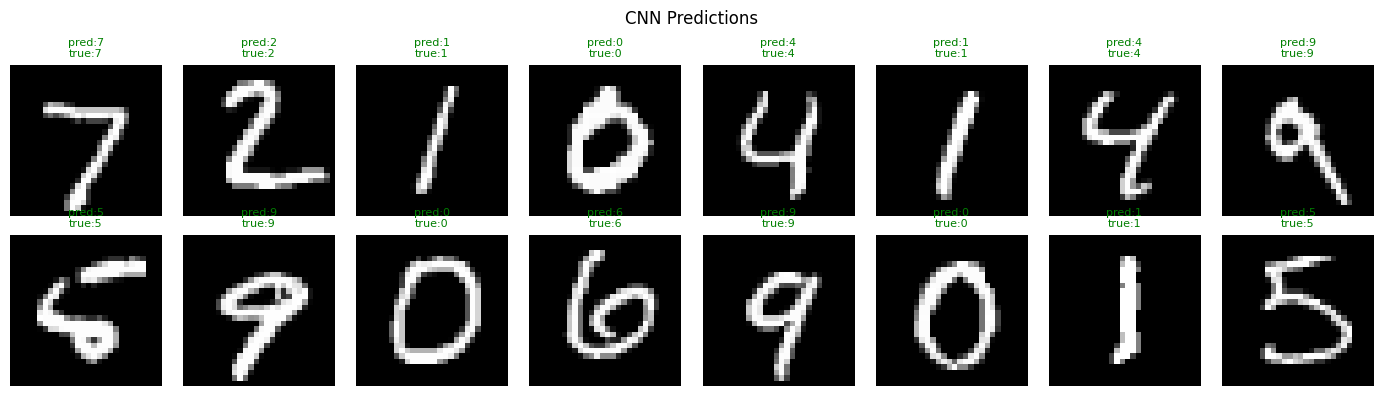

In [3]:
# ── Visualise predictions ─────────────────────────
def show_predictions(model, title):
    model.eval()
    imgs, labels = next(iter(test_loader))
    with torch.no_grad():
        preds = model(imgs).argmax(1)
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        correct = preds[i] == labels[i]
        ax.set_title(f"pred:{preds[i].item()}\ntrue:{labels[i].item()}",
                     color='green' if correct else 'red', fontsize=8)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

show_predictions(cnn_model, 'CNN Predictions')

FC Network — wrong: 238 / 10000


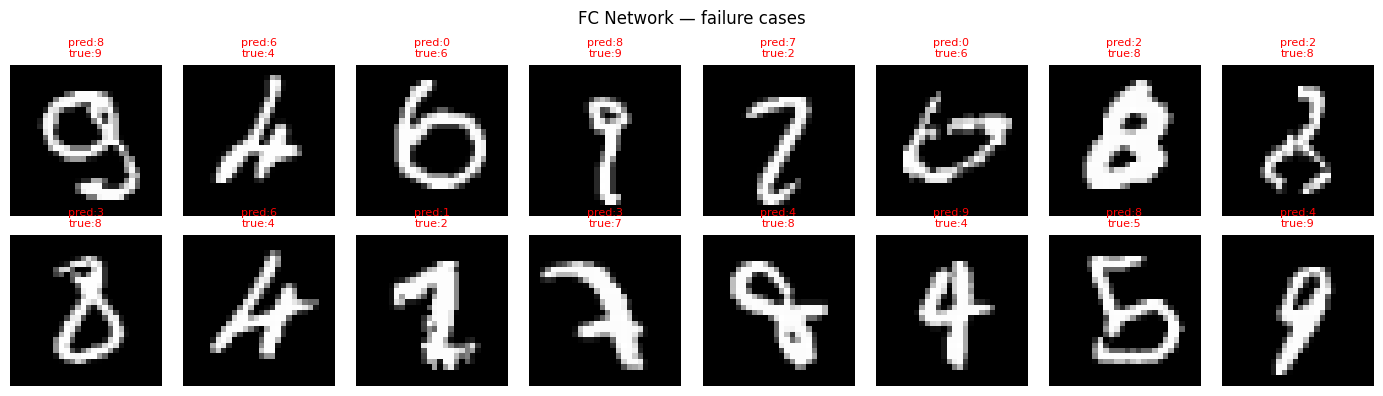

CNN — wrong: 92 / 10000


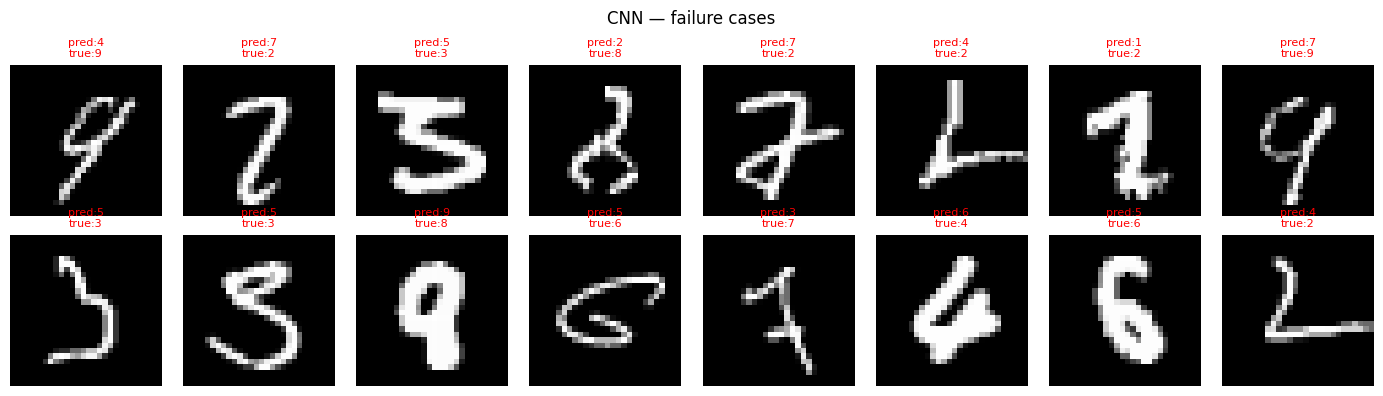


Key finding:
- Both models fail on the same kind of images: ambiguous handwriting
  where even humans would hesitate (e.g. a 4 written like a 9).
- FC Network ignores spatial structure — it sees 784 independent pixels.
- CNN learns local features (edges, curves) first, then combines them.
  This structural advantage accounts for the accuracy gap.



In [4]:
# ── Error analysis ────────────────────────────────
def show_errors(model, title):
    model.eval()
    wrong_imgs, wrong_preds, wrong_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            preds = model(imgs).argmax(1)
            mask  = preds != labels
            wrong_imgs.append(imgs[mask])
            wrong_preds.append(preds[mask])
            wrong_labels.append(labels[mask])
    wrong_imgs   = torch.cat(wrong_imgs)
    wrong_preds  = torch.cat(wrong_preds)
    wrong_labels = torch.cat(wrong_labels)
    print(f"{title} — wrong: {len(wrong_imgs)} / {len(test_data)}")

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(wrong_imgs[i].squeeze(), cmap='gray')
        ax.set_title(f"pred:{wrong_preds[i].item()}\ntrue:{wrong_labels[i].item()}",
                     color='red', fontsize=8)
        ax.axis('off')
    plt.suptitle(f'{title} — failure cases')
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_errors.png', dpi=150)
    plt.show()

show_errors(fc_model,  'FC Network')
show_errors(cnn_model, 'CNN')

# Key finding
print("""
Key finding:
- Both models fail on the same kind of images: ambiguous handwriting
  where even humans would hesitate (e.g. a 4 written like a 9).
- FC Network ignores spatial structure — it sees 784 independent pixels.
- CNN learns local features (edges, curves) first, then combines them.
  This structural advantage accounts for the accuracy gap.
""")